# Part 3: a distance-3 phase-flip repetition code

Parts 1 and 2 characterised the noise. This part asks the next question: does error correction help, and how much does the correlation of the noise change the answer?

## Why the phase-flip code

The noise modelled throughout is pure dephasing, i.e. $Z$ errors. The familiar repetition code $|0\rangle_L = |000\rangle$ with stabilisers $Z_1Z_2, Z_2Z_3$ protects against $X$ errors and would do nothing here. The code needed is its Hadamard conjugate:

$$|+\rangle_L = |{+}{+}{+}\rangle, \qquad |-\rangle_L = |{-}{-}{-}\rangle, \qquad \text{stabilisers } X_1X_2,\ X_2X_3$$

A single $Z$ error flips $|+\rangle \to |-\rangle$ on one qubit, the two stabilisers localise it, and majority vote corrects it. Two or more errors give a logical error. (A real device has both error types, which is exactly why one needs a 2D code such as the surface code rather than a repetition code — that is the step this notebook stops short of.)

## Error digitization

The noise does not produce discrete flips: it produces a continuous rotation $e^{-i\phi Z/2}$, so

$$e^{-i\phi Z/2}|+\rangle = \cos(\phi/2)\,|+\rangle - i\sin(\phi/2)\,|-\rangle$$

The qubit is in a superposition of "flipped" and "not flipped". Measuring the stabiliser collapses it, and the qubit is found flipped with probability $\sin^2(\phi/2)$. This is the foundational fact that makes QEC possible at all: syndrome measurement digitizes a continuous error into a discrete one, so a code designed for discrete Pauli errors can correct analog noise.

## Spatial correlation

Qubits sitting in the same FDSOI device share a charge environment, so their dephasing is not independent. Following the two-source decomposition of Part 1, each qubit's phase is split into a local and a shared part at fixed total variance:

$$\phi_i = \sqrt{1-c}\;\phi_i^{\text{local}} + \sqrt{c}\;\phi^{\text{shared}}, \qquad c \in [0,1]$$

so that $c$ is the correlation between any two qubits and the single-qubit error rate $\bar p$ is unchanged. $c=0$ is the textbook assumption; $c=1$ means all three qubits see the same field.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

# Same device as Parts 1 and 2: the electron spin qubit of the IEDM paper.
T2_star = 0.5                        # us
sigma_noise = np.sqrt(2) / T2_star   # rad/us, quasi-static relation T2* = sqrt(2)/sigma

n_shots = 400000   # number of encode-error-measure-decode cycles per point

In [2]:
def run_code(t_round, c, n_shots=n_shots, rng=rng):
    """One syndrome extraction round on a 3-qubit phase-flip code.
    t_round : duration over which each qubit accumulates phase (us)
    c       : fraction of the phase variance that is SHARED between the three qubits"""

    # accumulated phase of each qubit, quasi-static over the round: phi = eps * t_round.
    # The variance is split between a local and a shared part at FIXED TOTAL, exactly as in the
    # two-source model of Part 1, so that changing c does not change the single-qubit error rate.
    sigma_phi = sigma_noise * t_round
    phi_local = rng.normal(0.0, 1.0, size=(n_shots, 3))
    phi_shared = rng.normal(0.0, 1.0, size=(n_shots, 1))
    phi = sigma_phi * (np.sqrt(1-c) * phi_local + np.sqrt(c) * phi_shared)

    # qubit flipped with probability sin^2(phi/2).
    p_flip = np.sin(phi/2)**2
    flips = rng.random((n_shots, 3)) < p_flip

    logical_error = flips.sum(axis=1) >= 2

    return logical_error.mean(), p_flip.mean()

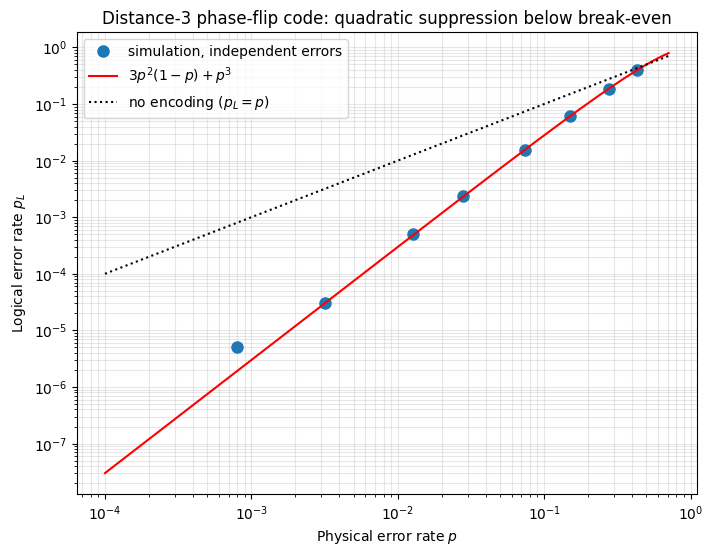

In [3]:
# Validation: with independent errors (c=0) the logical error rate of a distance-3 repetition code
# is the probability that at least 2 of 3 qubits flip:
#     p_L = 3 p^2 (1-p) + p^3
# The QUADRATIC leading term is the whole point of error correction: it is what turns a physical error rate into a much smaller logical one. It also shows the break-even point, p = 1/2 here,
# above which the code makes things worse rather than better.
t_list = np.array([0.02, 0.04, 0.08, 0.12, 0.2, 0.3, 0.45, 0.7])

p_phys, p_log = [], []
for t in t_list:
    pL, pbar = run_code(t, c=0.0)
    p_phys.append(pbar); p_log.append(pL)
p_phys, p_log = np.array(p_phys), np.array(p_log)

p_smooth = np.logspace(-4, -0.15, 200)
p_theory = 3*p_smooth**2*(1-p_smooth) + p_smooth**3

plt.figure(figsize=(8,6))
plt.loglog(p_phys, p_log, 'o', markersize=8, label='simulation, independent errors')
plt.loglog(p_smooth, p_theory, 'r-', label=r'$3p^2(1-p)+p^3$')
plt.loglog(p_smooth, p_smooth, 'k:', label='no encoding ($p_L = p$)')
plt.xlabel('Physical error rate $p$')
plt.ylabel('Logical error rate $p_L$')
plt.title('Distance-3 phase-flip code: quadratic suppression below break-even')
plt.legend()
plt.grid(True, alpha=0.3, which='both')
plt.show()

c = 0.0   p = 0.01956   p_L = 0.001077   p_L/p^2 = 2.82
c = 0.2   p = 0.01960   p_L = 0.001235   p_L/p^2 = 3.22
c = 0.4   p = 0.01963   p_L = 0.001417   p_L/p^2 = 3.68
c = 0.6   p = 0.01958   p_L = 0.001868   p_L/p^2 = 4.87
c = 0.8   p = 0.01959   p_L = 0.002318   p_L/p^2 = 6.04
c = 1.0   p = 0.01967   p_L = 0.003160   p_L/p^2 = 8.17


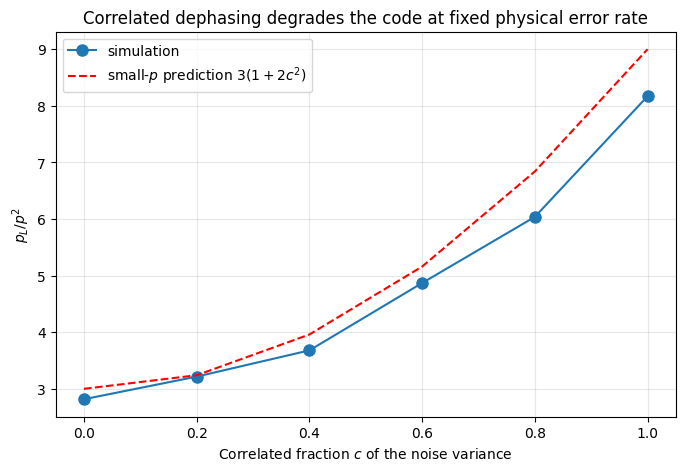

In [4]:
# Now the point of the notebook: what CORRELATED noise does. The single-qubit error rate p is held
# fixed while c is varied, so any change in p_L comes purely from the correlation.
# Mechanism: with shared noise, p itself FLUCTUATES from shot to shot, and since p_L ~ 3p^2 is
# convex, the average of the square exceeds the square of the average (Jensen). Concretely, for
# small phases and jointly Gaussian phases of correlation c, Isserlis' theorem gives  E[p_i p_j] = p_bar^2 (1 + 2c^2)   =>   p_L ~ 3 p_bar^2 (1 + 2c^2)
# so the logical error rate is up to a factor 3 worse at full correlation, at the SAME p.
# This is the same mechanism as in Part 2, where correlated noise made the RB decay a mixture of exponentials rather than a single one.
c_list = np.array([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
t_fixed = 0.1   # us

ratio = []
for c in c_list:
    pL, pbar = run_code(t_fixed, c)
    ratio.append(pL / pbar**2)
    print(f"c = {c:.1f}   p = {pbar:.5f}   p_L = {pL:.6f}   p_L/p^2 = {pL/pbar**2:.2f}")

plt.figure(figsize=(8,5))
plt.plot(c_list, ratio, 'o-', markersize=8, label='simulation')
plt.plot(c_list, 3*(1+2*c_list**2), 'r--', label=r'small-$p$ prediction $3(1+2c^2)$')
plt.xlabel('Correlated fraction $c$ of the noise variance')
plt.ylabel(r'$p_L / p^2$')
plt.title('Correlated dephasing degrades the code at fixed physical error rate')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()